# Entrega 3 — Chunking de Manifestações Longas

**Ouvidoria Inteligente: Triagem Semântica de Manifestações Cidadãs**

Manifestações longas perdem contexto quando são indexadas como um bloco só. Este notebook:

1. seleciona as **5 manifestações mais longas** do corpus;
2. divide cada uma com o **`RecursiveCharacterTextSplitter`** do LangChain em **4 configurações** de `(chunk_size, chunk_overlap)`: dois tamanhos, cada um com e sem overlap, para isolar o efeito do overlap;
3. mede a coesão entre chunks consecutivos e o quanto cada chunk preserva o sentido da denúncia;
4. projeta os chunks em 2D (PCA e t-SNE) e mede se os chunks de uma mesma manifestação ficam próximos.

Embeddings: `paraphrase-multilingual-MiniLM-L12-v2`, o mesmo modelo das Entregas 1 e 2.

In [1]:
import inspect
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

from ouvidoria import MODELO_PADRAO, carregar_manifestacoes, carregar_modelo, dividir_em_chunks, gerar_embeddings

pd.set_option("display.max_colwidth", 120)
df = pd.DataFrame(carregar_manifestacoes())
df["caracteres"] = df["texto"].str.len()
longas = df.sort_values("caracteres", ascending=False).head(5).reset_index(drop=True)
modelo = carregar_modelo(MODELO_PADRAO)
emb_40 = gerar_embeddings(df["texto"].tolist(), modelo)  # as 40 manifestações inteiras, para comparar com os chunks

print(f"{len(df)} manifestações · a 6ª mais longa tem {df['caracteres'].nlargest(6).iloc[-1]} caracteres")
longas[["id", "categoria_oficial", "caracteres", "texto"]]

40 manifestações · a 6ª mais longa tem 173 caracteres


,id,categoria_oficial,caracteres,texto
0,M025,educação,682,"Os alunos da Escola Municipal Frei Albino estão assistindo aula em salas sem ventilador, com temperatura acima de tr..."
1,M020,segurança,655,"Nos últimos dois meses, pelo menos seis casas da Rua Projetada 3, no conjunto Mangabeira, foram arrombadas durante o..."
2,M013,saúde,651,"Minha mãe tem 72 anos, é diabética e hipertensa, e precisa de consulta com cardiologista desde março. O encaminhamen..."
3,M005,infraestrutura,647,"Toda vez que chove forte, a Rua do Canal, no bairro Cidade Nova, vira um rio. Os bueiros estão entupidos há meses co..."
4,M032,meio ambiente,589,"Todos os anos, entre agosto e dezembro, colocam fogo no terreno ao lado do Rio Jaguaribe para limpar o mato, e a fum..."


## 1) O splitter

`dividir_em_chunks` (em `ouvidoria.py`) usa o `RecursiveCharacterTextSplitter` com a hierarquia de separadores **parágrafo → linha → frase (`". "`) → palavra → caractere**. Ele tenta cortar no separador mais "alto" e só desce um nível quando um pedaço não cabe no `chunk_size`. Depois junta os pedaços vizinhos até o limite e, entre um chunk e o seguinte, repete os **últimos pedaços inteiros** que somem no máximo `chunk_overlap` caracteres. `keep_separator="end"` mantém o ponto final no fim da frase.

In [2]:
print(inspect.getsource(dividir_em_chunks))

def dividir_em_chunks(texto: str, chunk_size: int, chunk_overlap: int, estrategia: str = "recursiva") -> list[str]:
    """Divide o texto com os splitters do LangChain.

    "recursiva": RecursiveCharacterTextSplitter (parágrafo → linha → frase → palavra → caractere).
    "fixa": CharacterTextSplitter separando só por espaço (tamanho fixo).
    """
    from langchain_text_splitters import (
        CharacterTextSplitter,
        RecursiveCharacterTextSplitter,
    )

    if estrategia == "recursiva":
        splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size, chunk_overlap=chunk_overlap, separators=["\n\n", "\n", ". ", " ", ""],
            keep_separator="end",
        )
    elif estrategia == "fixa":
        splitter = CharacterTextSplitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap, separator=" ")
    else:
        raise ValueError(f"estratégia desconhecida: {estrategia}")
    return splitter.split_text(texto)



## 2) As configurações testadas

| Config. | chunk_size | chunk_overlap | Ideia |
|---|---|---|---|
| A | 150 | 0 | ≈ 1 frase por chunk, sem overlap |
| B | 150 | 50 | ≈ 1 frase por chunk, overlap de 1/3 |
| C | 300 | 0 | ≈ 2 frases por chunk, sem overlap |
| D | 300 | 100 | ≈ 2 frases por chunk, overlap de 1/3 |

Os textos têm de 589 a 682 caracteres e frases de 17 a 178 caracteres. Com 150, as frases maiores precisam ser quebradas em palavras. Com 300, cabem de uma a três frases inteiras por chunk. Comparar A × B e C × D mostra o efeito do overlap com o tamanho fixo.

In [3]:
CONFIGS = {"A (150, 0)": (150, 0), "B (150, 50)": (150, 50), "C (300, 0)": (300, 0), "D (300, 100)": (300, 100)}
ids_40 = df["id"].tolist()


def sobreposicao(a: str, b: str) -> int:
    # Caracteres repetidos entre chunks consecutivos: o maior sufixo de a, em palavras inteiras, que também é prefixo de b.
    for k in range(min(len(a), len(b)), 0, -1):
        inteiro = (k == len(a) or a[-k - 1] == " ") and (k == len(b) or b[k] == " ")
        if inteiro and a.endswith(b[:k]):
            return k
    return 0


def fragmento(chunk: str) -> bool:
    # Chunk que começa no meio de uma frase (letra minúscula) ou termina sem pontuação final.
    return not chunk[0].isupper() or not chunk.rstrip().endswith((".", "!", "?"))


chunks = {}
for nome, (tamanho, overlap) in CONFIGS.items():
    registros = [
        {"id": m.id, "ordem": k + 1, "chunk": c, "caracteres": len(c)}
        for m in longas.itertuples()
        for k, c in enumerate(dividir_em_chunks(m.texto, tamanho, overlap))
    ]
    tab = pd.DataFrame(registros)
    E = gerar_embeddings(tab["chunk"].tolist(), modelo)
    tab["emb"] = list(E)
    # manifestação (entre as 40 inteiras) mais parecida com o chunk isolado
    tab["origem_prevista"] = [ids_40[i] for i in np.argmax(E @ emb_40.T, axis=1)]
    # similaridade do chunk com a própria manifestação inteira
    inteira = dict(zip(ids_40, emb_40))
    tab["sim_inteira"] = [float(e @ inteira[i]) for e, i in zip(E, tab["id"])]
    chunks[nome] = tab

pd.DataFrame({nome: tab.groupby("id", sort=False).size() for nome, tab in chunks.items()}).rename_axis("chunks por manifestação")

,"A (150, 0)","B (150, 50)","C (300, 0)","D (300, 100)"
chunks por manifestação,,,,
M025,7,7,3,4
M020,7,7,3,4
M013,7,7,3,3
M005,6,6,3,3
M032,7,7,3,3


### Os mesmos textos em cada configuração

M020 (arrombamentos no conjunto Mangabeira) ilustra as diferenças. Trechos repetidos por causa do overlap aparecem entre `[[ ]]`.

In [4]:
def mostrar(id_manif, nome):
    tab = chunks[nome][chunks[nome]["id"] == id_manif]["chunk"].tolist()
    print(f"── {nome}: {len(tab)} chunks")
    for k, c in enumerate(tab):
        ov = sobreposicao(tab[k - 1], c) if k else 0
        print(f"  {k + 1}. " + (f"[[{c[:ov]}]]{c[ov:]}" if ov else c))
    print()


for nome in CONFIGS:
    mostrar("M020", nome)

── A (150, 0): 7 chunks
  1. Nos últimos dois meses, pelo menos seis casas da Rua Projetada 3, no conjunto Mangabeira, foram arrombadas durante o dia, enquanto os moradores
  2. estavam no trabalho.
  3. Os ladrões levam televisão, botijão de gás e até as grades das janelas.
  4. Registramos boletim de ocorrência em todos os casos, mas nenhuma viatura passou pela rua depois disso.
  5. A iluminação também é precária, o que deixa a rua deserta e escura já no fim da tarde.
  6. Os moradores estão se organizando para pagar vigilância particular, mas a maioria não tem condição.
  7. Pedimos rondas regulares da polícia e da guarda municipal, instalação de câmeras no acesso ao conjunto e melhoria da iluminação.

── B (150, 50): 7 chunks
  1. Nos últimos dois meses, pelo menos seis casas da Rua Projetada 3, no conjunto Mangabeira, foram arrombadas durante o dia, enquanto os moradores
  2. [[arrombadas durante o dia, enquanto os moradores]] estavam no trabalho.
  3. Os ladrões levam televisão,

## 3) Métricas por configuração

- **Fragmentos:** chunks que começam no meio de uma frase ou terminam sem pontuação final.
- **Repetição:** caracteres repetidos pelo overlap ÷ caracteres dos textos originais.
- **Coesão consecutiva:** cosseno médio entre o chunk *k* e o chunk *k+1* da mesma manifestação.
- **Sim. com a manifestação inteira:** cosseno médio entre o chunk e a manifestação completa da qual ele saiu.
- **Recupera a origem:** % de chunks que, sozinhos, têm como manifestação mais similar entre as 40 a própria manifestação de origem. É o teste mais direto de "o chunk ainda diz do que é a denúncia".

In [5]:
def metricas(nome):
    tab = chunks[nome]
    coesao, overlaps = [], []
    for _, g in tab.groupby("id", sort=False):
        E, textos = np.stack(g["emb"]), g["chunk"].tolist()
        coesao += [float(E[k] @ E[k + 1]) for k in range(len(E) - 1)]
        overlaps += [sobreposicao(textos[k], textos[k + 1]) for k in range(len(textos) - 1)]
    repeticao = sum(overlaps) / longas["caracteres"].sum()
    return {
        "Chunks": len(tab),
        "Tamanho médio": round(tab["caracteres"].mean()),
        "Fragmentos": int(tab["chunk"].map(fragmento).sum()),
        "Transições com overlap": f"{sum(o > 0 for o in overlaps)}/{len(overlaps)}",
        "Repetição": round(float(repeticao), 2),
        "Coesão consecutiva": round(float(np.mean(coesao)), 3),
        "Sim. com a manifestação inteira": round(float(tab["sim_inteira"].mean()), 3),
        "Recupera a origem": round(float((tab["origem_prevista"] == tab["id"]).mean()), 2),
    }


resumo = pd.DataFrame({nome: metricas(nome) for nome in CONFIGS}).T
resumo

,Chunks,Tamanho médio,Fragmentos,Transições com overlap,Repetição,Coesão consecutiva,Sim. com a manifestação inteira,Recupera a origem
"A (150, 0)",34,94,10,0/29,0.0,0.223,0.501,0.74
"B (150, 50)",34,101,10,6/29,0.08,0.288,0.533,0.74
"C (300, 0)",15,214,0,0/10,0.0,0.48,0.726,0.87
"D (300, 100)",17,231,0,10/12,0.22,0.597,0.733,0.88


## 4) Como o overlap influencia a coesão semântica entre chunks consecutivos?

**O overlap aumenta a coesão.** A coesão consecutiva sobe de A para B e, mais ainda, de C para D (tabela acima): chunks vizinhos passam a compartilhar a frase de transição, então o chunk seguinte "lembra" do que veio antes.

**Mas o overlap do `RecursiveCharacterTextSplitter` não é uma janela deslizante de caracteres.** Ele repete **pedaços inteiros** do último nível de separador usado:

- **Em D (300, 100)** cabem frases inteiras no overlap, então cada chunk recomeça pela última frase do anterior. Em M020, “Os ladrões levam televisão…” fecha o chunk 1 e abre o chunk 2. A continuidade é natural, com frases completas.
- **Em B (150, 50)** quase nenhuma frase cabe inteira em 50 caracteres: só “Ninguém apareceu.” (M005, 17 caracteres); as outras têm de 63 a 178. Fora esse caso, o overlap só aparece onde uma frase longa teve de ser quebrada em palavras, e aí repete **meia frase**. Em M020, “arrombadas durante o dia, enquanto os moradores” aparece nos dois chunks. Na maioria das transições de B o overlap é zero (coluna *Transições com overlap*).
- **Um overlap menor que a menor frase não faz nada.** A célula abaixo mostra que, com `chunk_size` 250, os chunks com overlap 60 são idênticos aos sem overlap nas 5 manifestações. Com 300, a única diferença (M005) vem da frase curta “Ninguém apareceu.”, de 17 caracteres.

**Onde o overlap mais ajuda é no remendo dos cortes.** Em A, a frase de abertura de M020 é cortada e sobra o fragmento órfão “estavam no trabalho.”, sem sujeito nem verbo principal. Em B, o overlap devolve o contexto (“arrombadas durante o dia, enquanto os moradores estavam no trabalho.”), mas ainda sem dizer *o quê* foi arrombado. Por isso o overlap não compensa um `chunk_size` pequeno demais.

**Custo:** a coesão maior vem de texto repetido (coluna *Repetição*). Em D, pouco mais de um quinto do texto é indexado duas vezes, o que aumenta o índice e pode trazer o mesmo trecho duas vezes numa busca.

In [6]:
for tamanho, sem, com in [(250, 0, 60), (300, 0, 60)]:
    iguais = [m.id for m in longas.itertuples() if dividir_em_chunks(m.texto, tamanho, sem) == dividir_em_chunks(m.texto, tamanho, com)]
    print(f"chunk_size {tamanho}: overlap {sem} e {com} geram os mesmos chunks em {len(iguais)} de 5 manifestações ({', '.join(iguais)})")

frases = {m.id: [len(f) for f in re.split(r"(?<=[.!?])\s+", m.texto)] for m in longas.itertuples()}
print("tamanho das frases (caracteres):", frases)

chunk_size 250: overlap 0 e 60 geram os mesmos chunks em 5 de 5 manifestações (M025, M020, M013, M005, M032)
chunk_size 300: overlap 0 e 60 geram os mesmos chunks em 4 de 5 manifestações (M025, M020, M013, M032)
tamanho das frases (caracteres): {'M025': [143, 66, 140, 77, 73, 178], 'M020': [164, 71, 102, 86, 99, 128], 'M013': [101, 89, 71, 94, 120, 171], 'M005': [77, 115, 135, 116, 17, 72, 109], 'M032': [154, 90, 118, 63, 160]}


## 5) Qual configuração preserva melhor o sentido das denúncias?

**D (300, 100).** Ela tem a maior similaridade com a manifestação inteira, a maior taxa de chunks que recuperam a própria origem e nenhum fragmento. Cada chunk carrega de 2 a 3 frases completas: o problema, o lugar ou a consequência, e às vezes o pedido. A célula abaixo lista os chunks que, sozinhos, "apontam" para a manifestação errada:

- **Em A e B (150)**, os chunks de uma frase perdem o sujeito da denúncia. “A iluminação também é precária…” (M020, arrombamentos) vira uma queixa de iluminação e aponta para M031 (lâmpada queimada). “Registramos boletim de ocorrência…” aponta para outra manifestação. “Crianças e idosos com asma e bronquite vão parar na UPA…” (M032, queimadas) aponta para a escola sem ventilador. Fragmentos como “irregular.” não têm sentido algum.
- **Em D** sobram dois erros, em chunks que não citam o problema principal. O de M020 fala de iluminação e de vigilância particular, sem os arrombamentos, e aponta para M031 (praça no escuro). O de M005 fala de mosquito, mau cheiro e limpeza, e aponta para M007 (terreno com lixo, rato e mau cheiro). Nos acertos, o contexto fica junto: o chunk inicial de M025 une “salas sem ventilador… acima de trinta e cinco graus” e “Várias crianças passaram mal”. Em A, a segunda frase fica sozinha e não diz *por que* as crianças passaram mal.

C (300, 0) chega perto de D com menos repetição. É uma alternativa razoável quando o custo do índice pesa. O ganho de D está na coesão e na proximidade dos chunks (seção 6). Aumentar ainda mais o `chunk_size` também eleva a similaridade com o texto inteiro, mas acaba com a razão de fazer chunking: com 682 caracteres ou mais, cada manifestação vira um chunk só.

In [7]:
for nome in CONFIGS:
    tab = chunks[nome]
    erros = tab[tab["origem_prevista"] != tab["id"]]
    print(f"── {nome}: {len(erros)} de {len(tab)} chunks apontam para outra manifestação")
    for r in erros.itertuples():
        print(f"   {r.id} → {r.origem_prevista}: {r.chunk[:100]}{'…' if len(r.chunk) > 100 else ''}")
    print()

── A (150, 0): 9 de 34 chunks apontam para outra manifestação
   M025 → M001: A quadra está interditada desde o ano passado porque parte do alambrado caiu.
   M020 → M022: Registramos boletim de ocorrência em todos os casos, mas nenhuma viatura passou pela rua depois diss…
   M020 → M031: A iluminação também é precária, o que deixa a rua deserta e escura já no fim da tarde.
   M020 → M004: Pedimos rondas regulares da polícia e da guarda municipal, instalação de câmeras no acesso ao conjun…
   M013 → M019: O encaminhamento foi feito pela unidade básica, mas até hoje a regulação não marcou nada.
   M005 → M007: Além do prejuízo, a água parada atrai mosquito e o mau cheiro dura dias.
   M005 → M007: Pedimos a limpeza urgente dos bueiros e uma avaliação da galeria pluvial, porque o problema piora a …
   M032 → M025: Crianças e idosos com asma e bronquite vão parar na UPA, e a fuligem suja roupas e móveis.
   M032 → M036: irregular.

── B (150, 50): 9 de 34 chunks apontam para outra manifes

## 6) Visualização em 2D: os chunks de uma mesma manifestação ficam próximos?

Cada ponto é um chunk, a cor é a manifestação de origem e as linhas ligam chunks consecutivos. Primeira linha: PCA. Segunda linha: t-SNE (perplexidade 5, `random_state=42`).

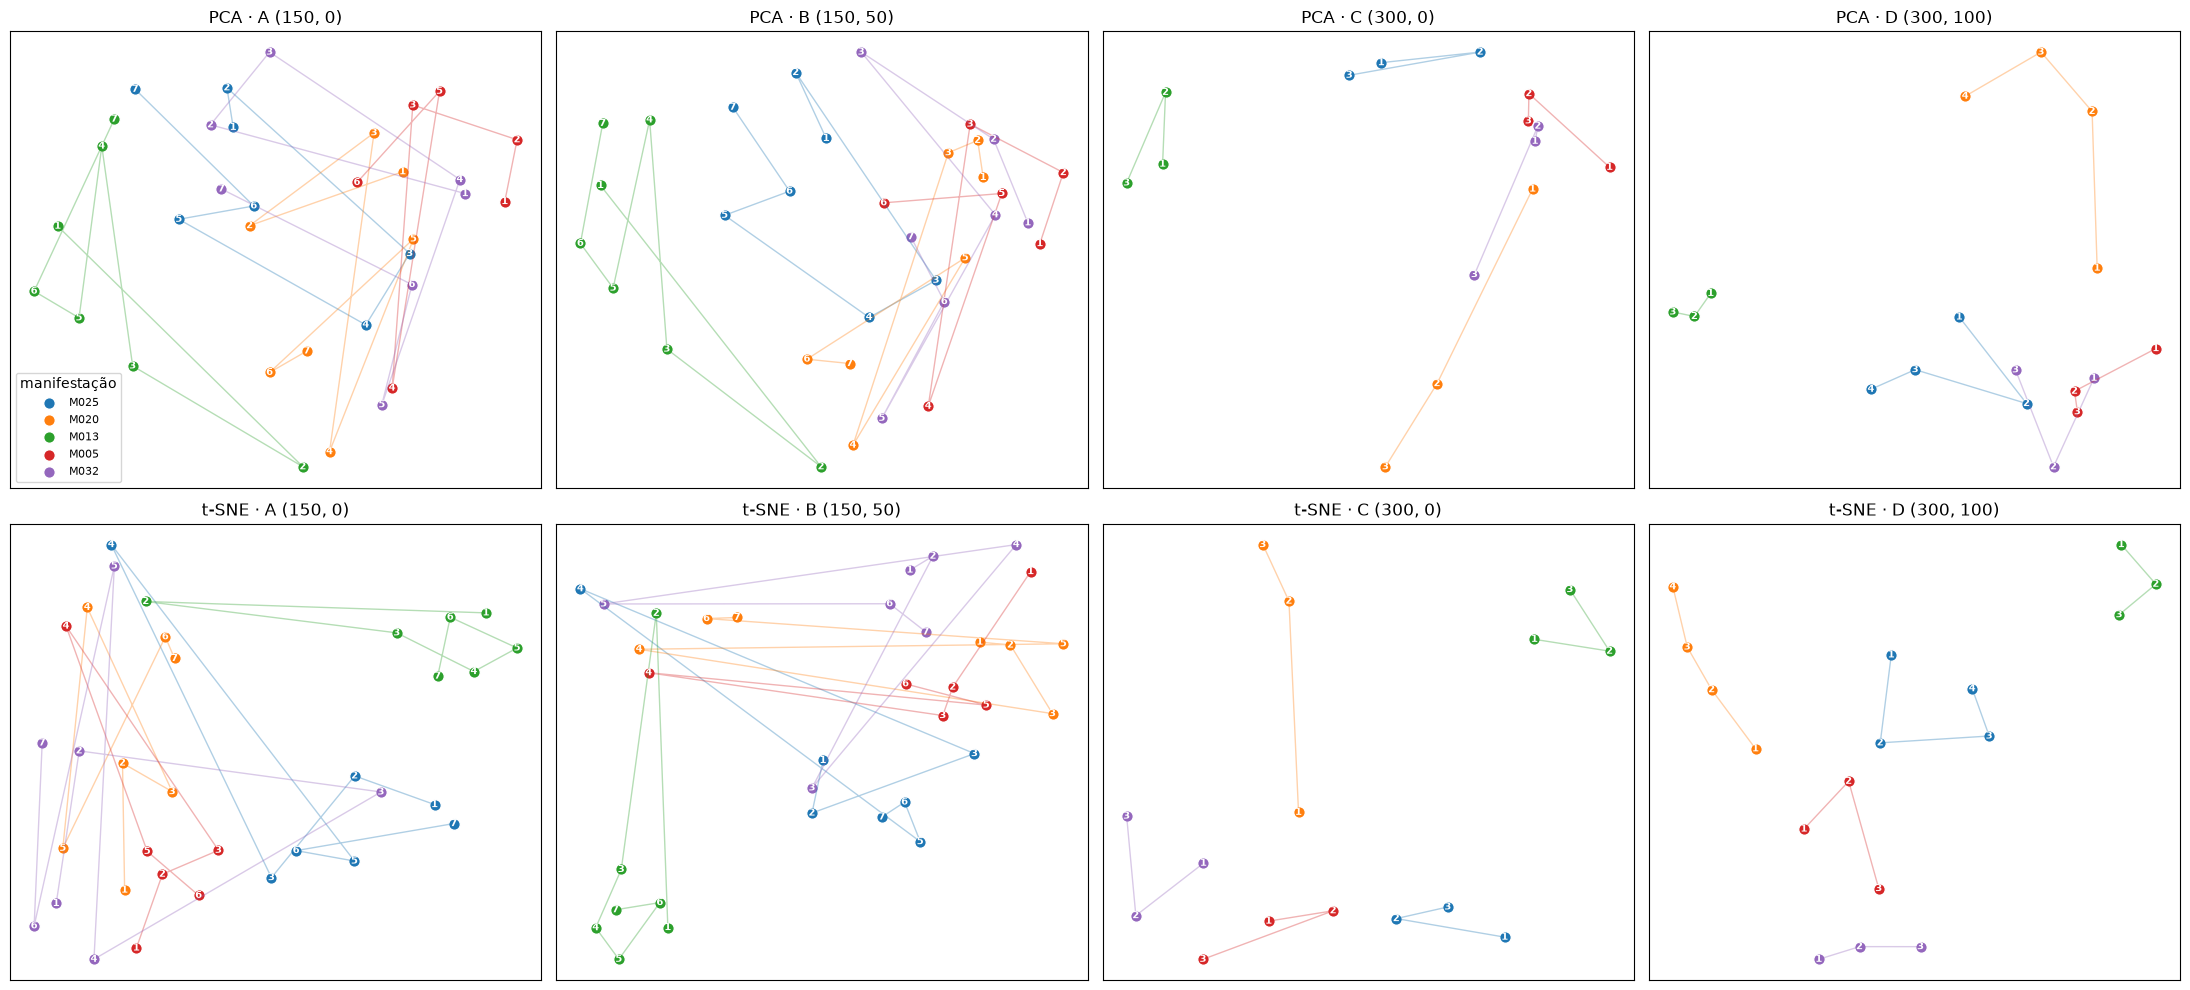

In [8]:
cores = dict(zip(longas["id"], plt.cm.tab10.colors))
proj = {}
fig, eixos = plt.subplots(2, 4, figsize=(22, 10))
for col, nome in enumerate(CONFIGS):
    tab = chunks[nome]
    E = np.stack(tab["emb"])
    proj[nome] = {
        "PCA": PCA(n_components=2, random_state=0).fit_transform(E),
        "t-SNE": TSNE(n_components=2, perplexity=5, init="pca", random_state=42).fit_transform(E),
    }
    for lin, metodo in enumerate(["PCA", "t-SNE"]):
        ax, P = eixos[lin, col], proj[nome][metodo]
        for mid, g in tab.groupby("id", sort=False):
            pts = P[g.index]
            ax.plot(pts[:, 0], pts[:, 1], color=cores[mid], alpha=0.35, linewidth=1)
            ax.scatter(pts[:, 0], pts[:, 1], color=cores[mid], s=70, label=mid, edgecolor="white")
            for (x, y), k in zip(pts, g["ordem"]):
                ax.annotate(str(k), (x, y), fontsize=7, ha="center", va="center", color="white", weight="bold")
        ax.set_title(f"{metodo} · {nome}")
        ax.set_xticks([])
        ax.set_yticks([])
eixos[0, 0].legend(title="manifestação", fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
def proximidade(nome):
    tab = chunks[nome]
    E, rot = np.stack(tab["emb"]), tab["id"].to_numpy()
    S = E @ E.T
    mesma = rot[:, None] == rot[None, :]
    i, j = np.triu_indices(len(rot), 1)
    np.fill_diagonal(S, -np.inf)
    vizinho = rot[np.argmax(S, axis=1)]
    return {
        "Sim. média (mesma manifestação)": round(float((E @ E.T)[i, j][mesma[i, j]].mean()), 3),
        "Sim. média (manifestações diferentes)": round(float((E @ E.T)[i, j][~mesma[i, j]].mean()), 3),
        "Vizinho mais próximo é da mesma": round(float((vizinho == rot).mean()), 2),
        "Silhueta (espaço original, cosseno)": round(float(silhouette_score(E, rot, metric="cosine")), 3),
        "Silhueta PCA 2D": round(float(silhouette_score(proj[nome]["PCA"], rot)), 3),
        "Silhueta t-SNE 2D": round(float(silhouette_score(proj[nome]["t-SNE"], rot)), 3),
    }


prox = pd.DataFrame({nome: proximidade(nome) for nome in CONFIGS}).T
variancia_pca = {nome: PCA(n_components=2).fit(np.stack(t["emb"])).explained_variance_ratio_.sum() for nome, t in chunks.items()}
print("Variância explicada pelas 2 componentes do PCA:", {k: f"{v:.0%}" for k, v in variancia_pca.items()})
prox

Variância explicada pelas 2 componentes do PCA: {'A (150, 0)': '21%', 'B (150, 50)': '22%', 'C (300, 0)': '35%', 'D (300, 100)': '38%'}


,Sim. média (mesma manifestação),Sim. média (manifestações diferentes),Vizinho mais próximo é da mesma,"Silhueta (espaço original, cosseno)",Silhueta PCA 2D,Silhueta t-SNE 2D
"A (150, 0)",0.221,0.126,0.59,0.031,-0.047,0.071
"B (150, 50)",0.263,0.144,0.62,0.050,-0.025,0.105
"C (300, 0)",0.470,0.228,0.73,0.164,0.178,0.413
"D (300, 100)",0.525,0.254,0.82,0.223,0.245,0.421


In [10]:
vizinhos_a = []
tab = chunks["A (150, 0)"]
E = np.stack(tab["emb"])
S = E @ E.T
np.fill_diagonal(S, -np.inf)
for k, v in enumerate(np.argmax(S, axis=1)):
    if tab["id"][k] != tab["id"][v]:
        vizinhos_a.append((tab["id"][k], tab["chunk"][k][:70], tab["id"][v], tab["chunk"][v][:70], S[k, v]))
print(f"Config. A: {len(vizinhos_a)} de {len(tab)} chunks têm como vizinho mais próximo um chunk de OUTRA manifestação, por exemplo:")
for a, ca, b, cb, s in vizinhos_a[:8]:
    print(f"  {a} «{ca}…»\n    ↔ {b} «{cb}…»  (cos = {s:.2f})")

Config. A: 14 de 34 chunks têm como vizinho mais próximo um chunk de OUTRA manifestação, por exemplo:
  M025 «Várias crianças passaram mal e tiveram de ser buscadas pelos pais.…»
    ↔ M032 «Crianças e idosos com asma e bronquite vão parar na UPA, e a fuligem s…»  (cos = 0.51)
  M025 «A quadra está interditada desde o ano passado porque parte do alambrad…»
    ↔ M032 «Denunciamos ao órgão ambiental no ano passado e nada foi feito.…»  (cos = 0.44)
  M025 «Pedimos uma vistoria na escola e um prazo para a instalação dos ventil…»
    ↔ M005 «Na última chuva a água chegou a quarenta centímetros dentro da minha s…»  (cos = 0.43)
  M020 «Nos últimos dois meses, pelo menos seis casas da Rua Projetada 3, no c…»
    ↔ M005 «Os bueiros estão entupidos há meses com terra e lixo acumulado, e a ág…»  (cos = 0.52)
  M020 «estavam no trabalho.…»
    ↔ M032 «dias.…»  (cos = 0.38)
  M020 «Os ladrões levam televisão, botijão de gás e até as grades das janelas…»
    ↔ M005 «Na última chuva a água chegou a

### Resposta

**Depende do tamanho do chunk. Com a configuração D, sim. Com chunks de uma frase, não.**

- **D (300, 100):** a maior parte dos chunks tem como vizinho mais próximo outro chunk da mesma manifestação. A similaridade média dentro da manifestação é cerca do dobro da similaridade entre manifestações diferentes. No t-SNE, os chunks de cada denúncia formam trilhas curtas e separadas. O overlap ajuda aqui também: chunks consecutivos compartilham uma frase e ficam colados.
- **A e B (150):** os chunks se espalham e se agrupam por **assunto da frase**, e não pela denúncia de origem. Frases sobre burocracia se atraem (“Registramos boletim de ocorrência…” de M020 × “Os vizinhos já abriram três protocolos…” de M005), assim como frases sobre danos à saúde (“Várias crianças passaram mal…” de M025 × “Crianças e idosos com asma…” de M032). A silhueta fica perto de zero, ou seja, não há grupos definidos.
- **PCA × t-SNE:** o PCA com 2 componentes guarda de um quinto a pouco mais de um terço da variância dos 384 eixos (valores impressos acima), então a imagem sobrepõe grupos que estão separados no espaço original. O t-SNE preserva vizinhanças locais e mostra melhor os grupos. As conclusões acima valem para o espaço original (colunas de similaridade e de vizinho mais próximo) e não dependem da projeção.

## 7) Conclusão

- **O overlap aumenta a coesão entre chunks consecutivos**, mas no `RecursiveCharacterTextSplitter` ele age em frases inteiras (ou palavras, quando a frase foi quebrada). Um overlap menor que as frases do texto não tem efeito, e o ganho custa texto repetido no índice.
- **A configuração que melhor preserva o sentido das denúncias é D (300, 100):** chunks de 2 a 3 frases completas, uma frase de overlap, sem fragmentos, e com a maior taxa de chunks que apontam para a própria manifestação.
- **Os chunks de uma mesma manifestação ficam próximos quando carregam contexto suficiente.** Com chunks de uma frase, a proximidade passa a refletir o assunto da frase (burocracia, danos à saúde), e não a denúncia.
- **Na prática da ouvidoria:** indexar as manifestações longas em chunks de ≈ 300 caracteres com uma frase de overlap e, na busca, devolver a manifestação de origem do chunk encontrado, não o chunk solto.